In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_excel("incident.xlsx")

# Remove ticket number immediately
df = df.drop(columns=['Number'])

print("Total Tickets:", len(df))
print("Columns:", list(df.columns))
df.head()

Total Tickets: 156570
Columns: ['System Updated on', 'Opened_at', 'Short_description', 'Priority', 'State', 'Category', 'Subcategory', 'u_country', 'cmdb_ci', 'assignment_group', 'close_notes']


,System Updated on,Opened_at,Short_description,Priority,State,Category,Subcategory,u_country,cmdb_ci,assignment_group,close_notes
0,2026-05-27 03:57:43,2026-05-27 03:56:59,User is unable to access sharepoint,3 - Moderate,In Progress,Enterprise Software,SharePoint,Portugal,NaN,IMS - Service Desk,NaN
1,2026-05-27 04:00:05,2026-05-27 03:48:02,"URL Down -Alert Triggered :-The URL ""https://w...",4 - Low,In Progress,Security,Cyber Threat Investigation (CTI),NaN,NaN,DCS - SecOps,NaN
2,2026-05-27 03:59:58,2026-05-27 03:48:00,"Reset Alert : Alert Triggered :-The URL ""https...",4 - Low,In Progress,Security,Cyber Threat Investigation (CTI),NaN,NaN,DCS - SecOps,NaN
3,2026-05-27 03:59:50,2026-05-27 03:47:57,"URL Down -Alert Triggered :-The URL ""uat-live-...",4 - Low,In Progress,Security,Cyber Threat Investigation (CTI),NaN,NaN,DCS - SecOps,NaN
4,2026-05-27 03:59:41,2026-05-27 03:47:56,"URL Down -Alert Triggered :-The URL ""https://u...",4 - Low,In Progress,Security,Cyber Threat Investigation (CTI),NaN,NaN,DCS - SecOps,NaN


In [8]:
# Check missing values before cleaning
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Drop columns only if they exist
cols_to_drop = ['cmdb_ci', 'u_country', 'close_notes', 'Number']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

# Drop rows where important columns are missing
df = df.dropna(subset=['Category', 'Short_description', 'assignment_group'])

# Fill subcategory missing values with Unknown
df['Subcategory'] = df['Subcategory'].fillna('Unknown')

# Convert Short_description to string
df['Short_description'] = df['Short_description'].astype(str)

# Reset index
df = df.reset_index(drop=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
print("\nTotal Tickets after cleaning:", len(df))

Missing Values Before Cleaning:
System Updated on     0
Opened_at             0
Short_description     0
Priority              0
State                 0
Category              0
Subcategory          66
assignment_group      0
dtype: int64

Missing Values After Cleaning:
System Updated on    0
Opened_at            0
Short_description    0
Priority             0
State                0
Category             0
Subcategory          0
assignment_group     0
dtype: int64

Total Tickets after cleaning: 156005


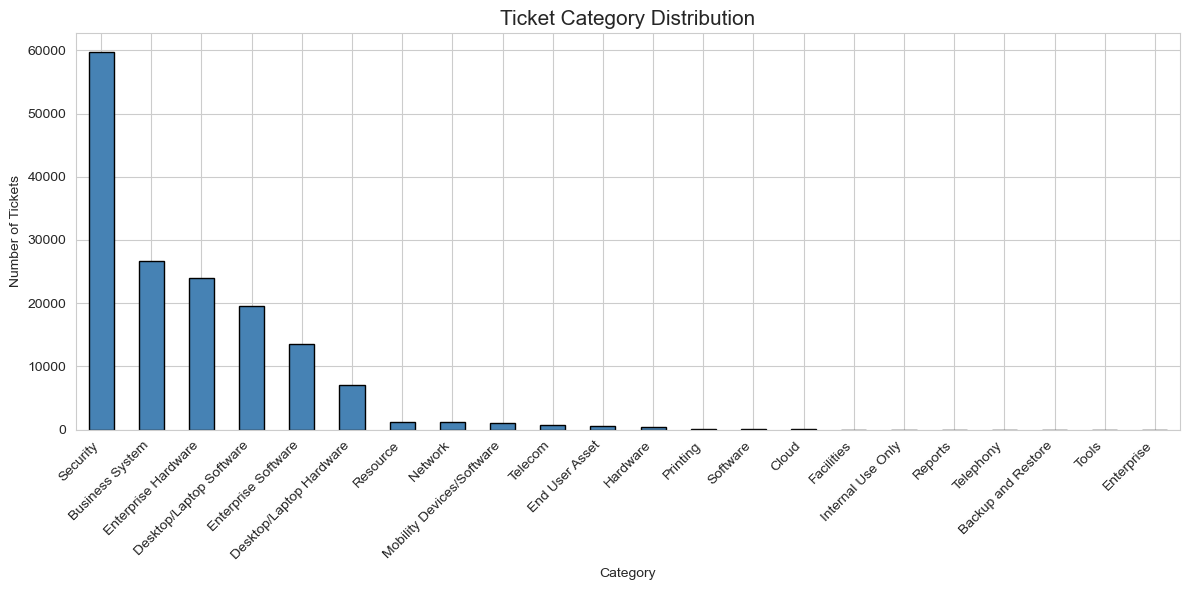

Chart 1 done! ✅


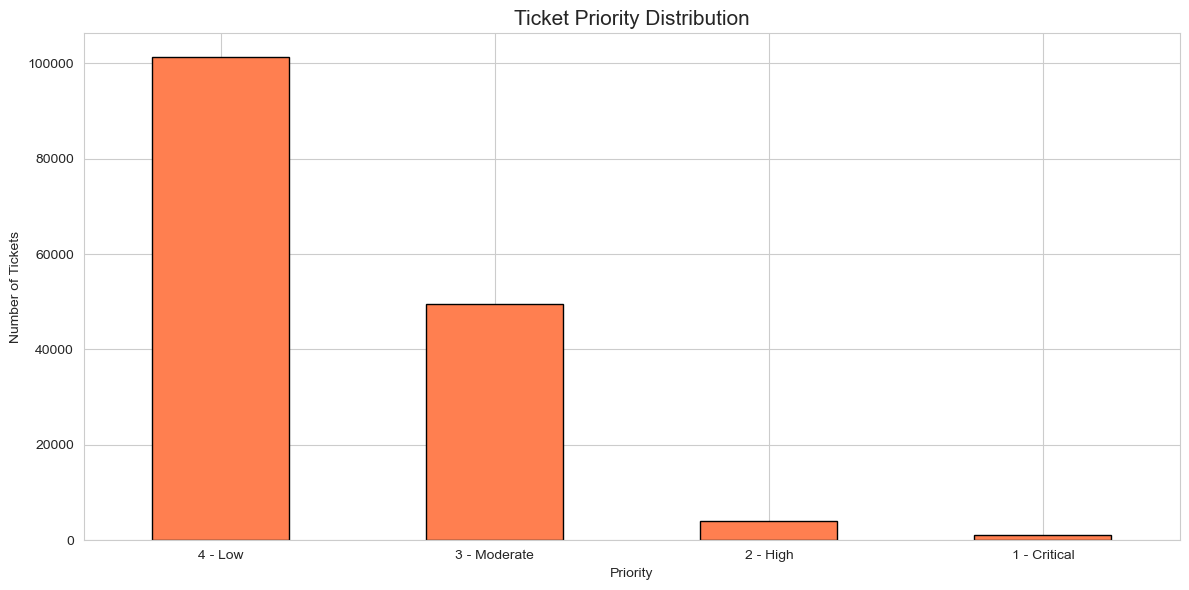

Chart 2 done! ✅


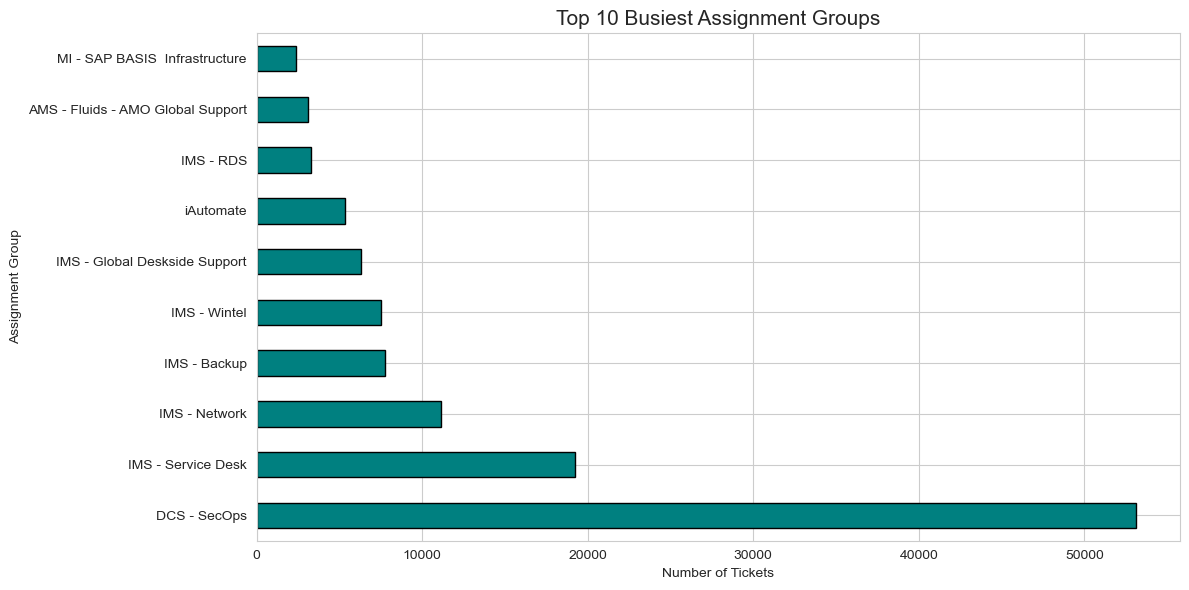

Chart 3 done! ✅


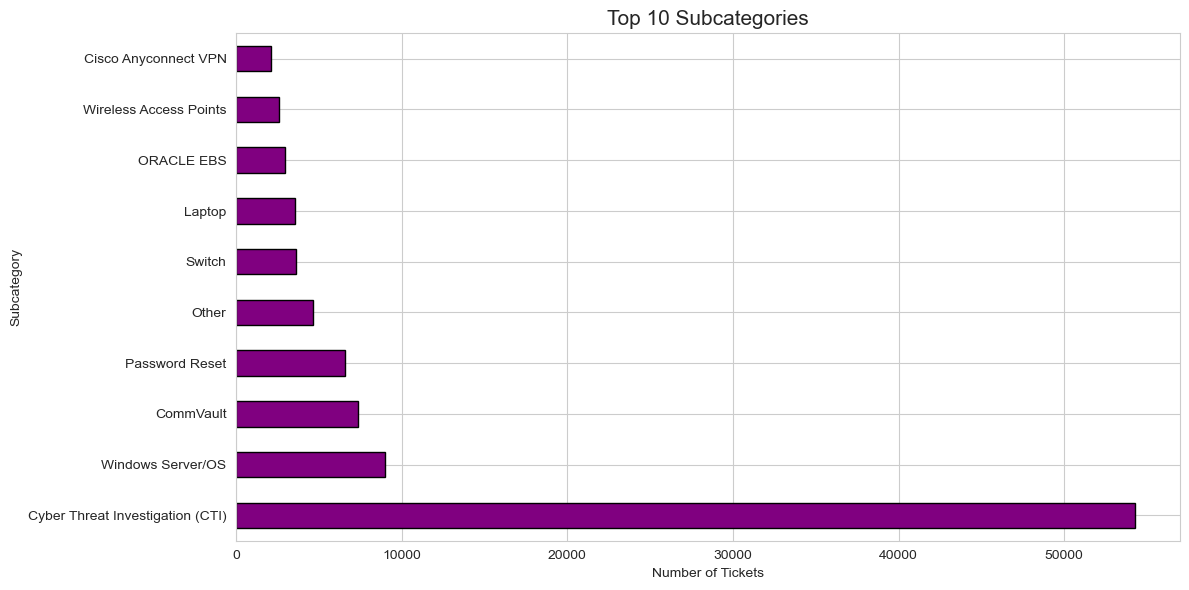

Chart 4 done! ✅


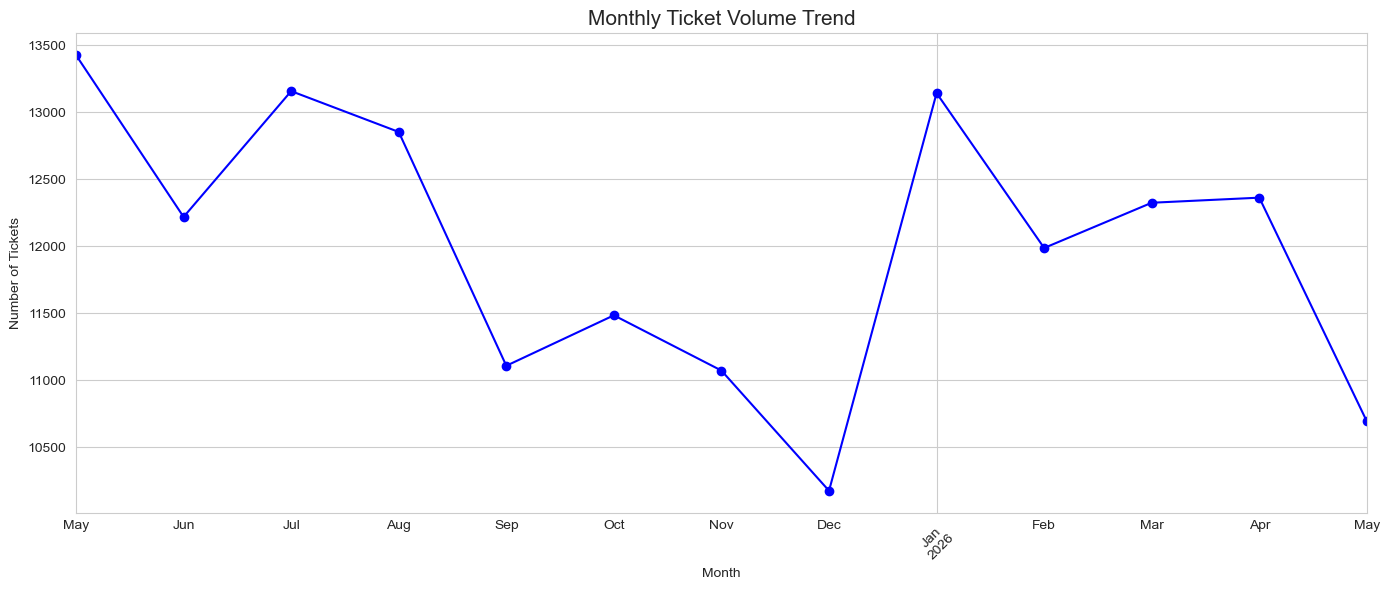

Chart 5 done! ✅


In [11]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chart 1 — Category Distribution
plt.figure()
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Ticket Category Distribution', fontsize=15)
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_category.png')
plt.show()
print("Chart 1 done! ✅")

# Chart 2 — Priority Distribution
plt.figure()
df['Priority'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Ticket Priority Distribution', fontsize=15)
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_priority.png')
plt.show()
print("Chart 2 done! ✅")

# Chart 3 — Top 10 Assignment Groups
plt.figure(figsize=(12, 6))
df['assignment_group'].value_counts().head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Busiest Assignment Groups', fontsize=15)
plt.xlabel('Number of Tickets')
plt.ylabel('Assignment Group')
plt.tight_layout()
plt.savefig('chart3_assignment.png')
plt.show()
print("Chart 3 done! ✅")

# Chart 4 — Top 10 Subcategories
plt.figure(figsize=(12, 6))
df['Subcategory'].value_counts().head(10).plot(kind='barh', color='purple', edgecolor='black')
plt.title('Top 10 Subcategories', fontsize=15)
plt.xlabel('Number of Tickets')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.savefig('chart4_subcategory.png')
plt.show()
print("Chart 4 done! ✅")

# Chart 5 — Monthly Ticket Volume Trend
df['Opened_at'] = pd.to_datetime(df['Opened_at'])
df['Month'] = df['Opened_at'].dt.to_period('M')
plt.figure(figsize=(14, 6))
df['Month'].value_counts().sort_index().plot(kind='line', color='blue', marker='o')
plt.title('Monthly Ticket Volume Trend', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png')
plt.show()
print("Chart 5 done! ✅")

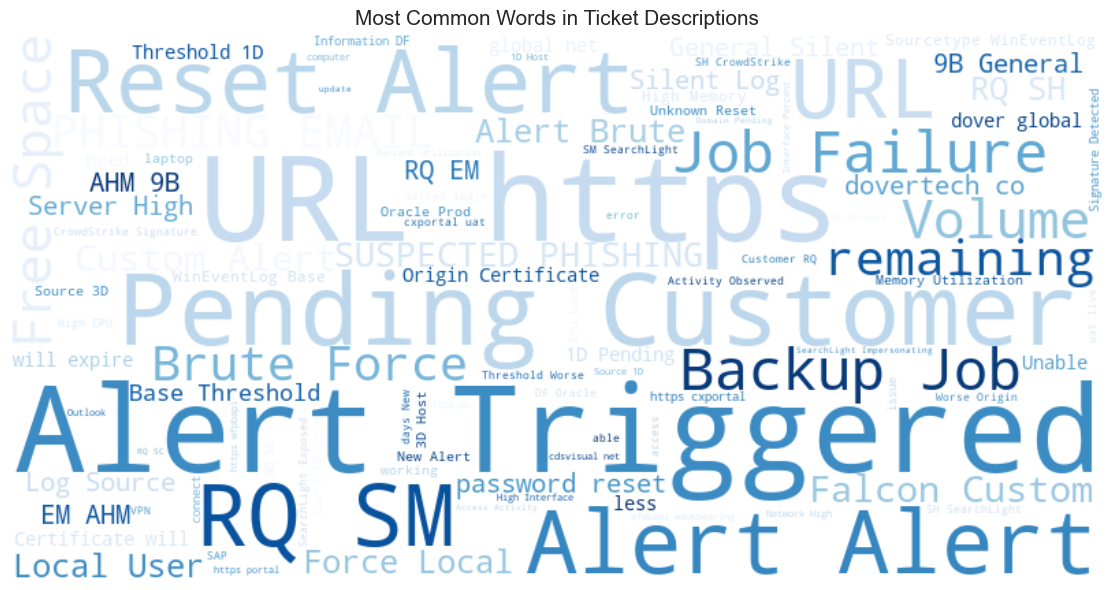

Word Cloud done! ✅


In [13]:
from wordcloud import WordCloud

# Convert to string and join all descriptions
text = " ".join(df['Short_description'].dropna().astype(str).values)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Blues',
                      max_words=100).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Ticket Descriptions', fontsize=15)
plt.tight_layout()
plt.savefig('chart6_wordcloud.png')
plt.show()
print("Word Cloud done! ✅")

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# Input = ticket description, Output = category
X = df['Short_description'].astype(str)
y = df['Category']

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)

# Build model pipeline
category_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000,
                               ngram_range=(1,2),
                               stop_words='english')),
    ('clf', LinearSVC(max_iter=2000))
])

# Train the model
print("Training Category Model... please wait!")
category_model.fit(X_train, y_train)

# Test the model
y_pred_cat = category_model.predict(X_test)
cat_accuracy = accuracy_score(y_test, y_pred_cat)

print(f"\n✅ Category Model Accuracy: {cat_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_cat))

Training Category Model... please wait!

✅ Category Model Accuracy: 87.44%

Detailed Report:
                           precision    recall  f1-score   support

       Backup and Restore       0.00      0.00      0.00         1
          Business System       0.80      0.86      0.83      5301
                    Cloud       0.00      0.00      0.00        14
  Desktop/Laptop Hardware       0.69      0.68      0.68      1462
  Desktop/Laptop Software       0.71      0.72      0.71      3962
           End User Asset       0.72      0.16      0.26       113
      Enterprise Hardware       0.90      0.97      0.93      4694
      Enterprise Software       0.86      0.76      0.81      2709
               Facilities       0.00      0.00      0.00         2
                 Hardware       0.90      0.56      0.69        81
        Internal Use Only       0.00      0.00      0.00         3
Mobility Devices/Software       0.67      0.57      0.62       229
                  Network       0.6

In [15]:
# Use only top 10 assignment groups
top_groups = df['assignment_group'].value_counts().head(10).index
df_filtered = df[df['assignment_group'].isin(top_groups)]

# Input = description + category combined
X2 = (df_filtered['Short_description'].astype(str) + " " +
      df_filtered['Category'].astype(str))
y2 = df_filtered['assignment_group']

# Split 80% training, 20% testing
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2,
                                                          test_size=0.2,
                                                          random_state=42)

# Build model pipeline
assignment_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000,
                               ngram_range=(1,2),
                               stop_words='english')),
    ('clf', LinearSVC(max_iter=2000))
])

# Train the model
print("Training Assignment Group Model... please wait!")
assignment_model.fit(X2_train, y2_train)

# Test the model
y2_pred = assignment_model.predict(X2_test)
assign_accuracy = accuracy_score(y2_test, y2_pred)

print(f"\n✅ Assignment Group Model Accuracy: {assign_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y2_test, y2_pred))

Training Assignment Group Model... please wait!

✅ Assignment Group Model Accuracy: 88.90%

Detailed Report:
                                   precision    recall  f1-score   support

AMS - Fluids - AMO Global Support       0.88      0.89      0.89       648
                     DCS - SecOps       0.99      0.99      0.99     10609
                     IMS - Backup       0.98      0.99      0.98      1548
    IMS - Global Deskside Support       0.58      0.53      0.55      1282
                    IMS - Network       0.96      0.91      0.93      2198
                        IMS - RDS       0.44      0.24      0.31       621
               IMS - Service Desk       0.77      0.86      0.81      3853
                     IMS - Wintel       0.78      0.77      0.77      1506
   MI - SAP BASIS  Infrastructure       0.94      0.93      0.93       472
                        iAutomate       0.75      0.77      0.76      1088

                         accuracy                           0.89

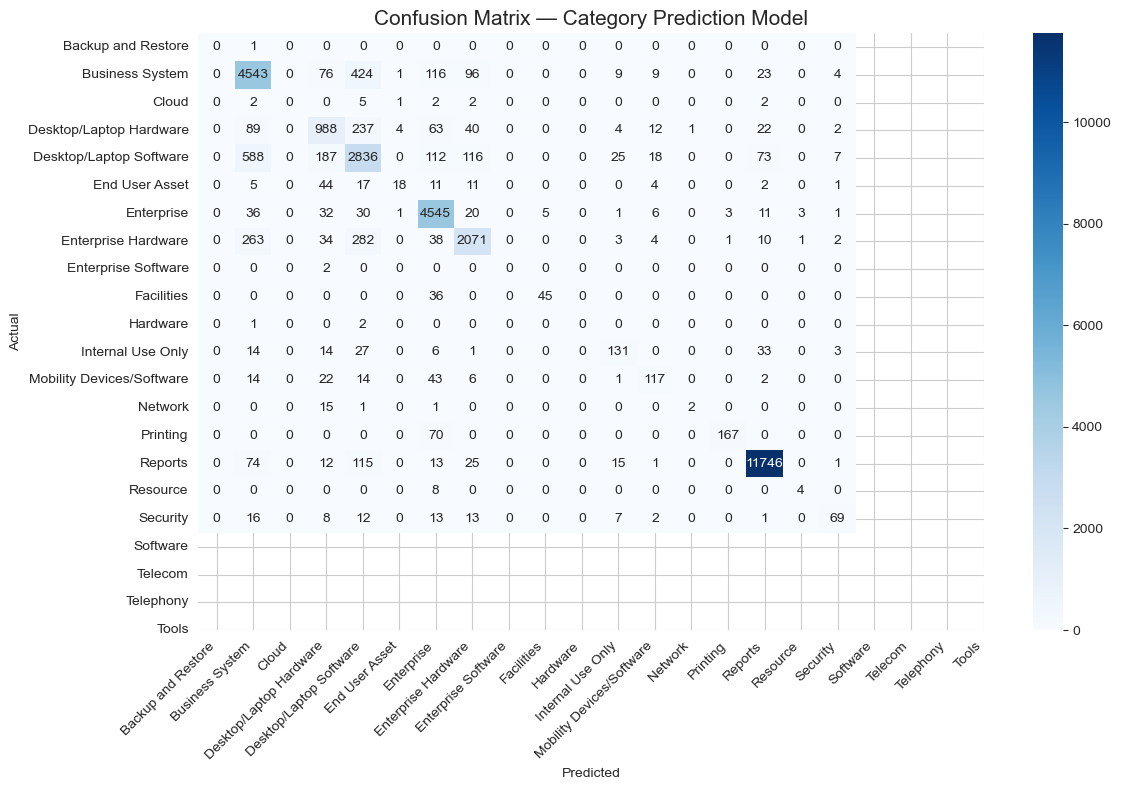

Confusion Matrix 1 done! ✅


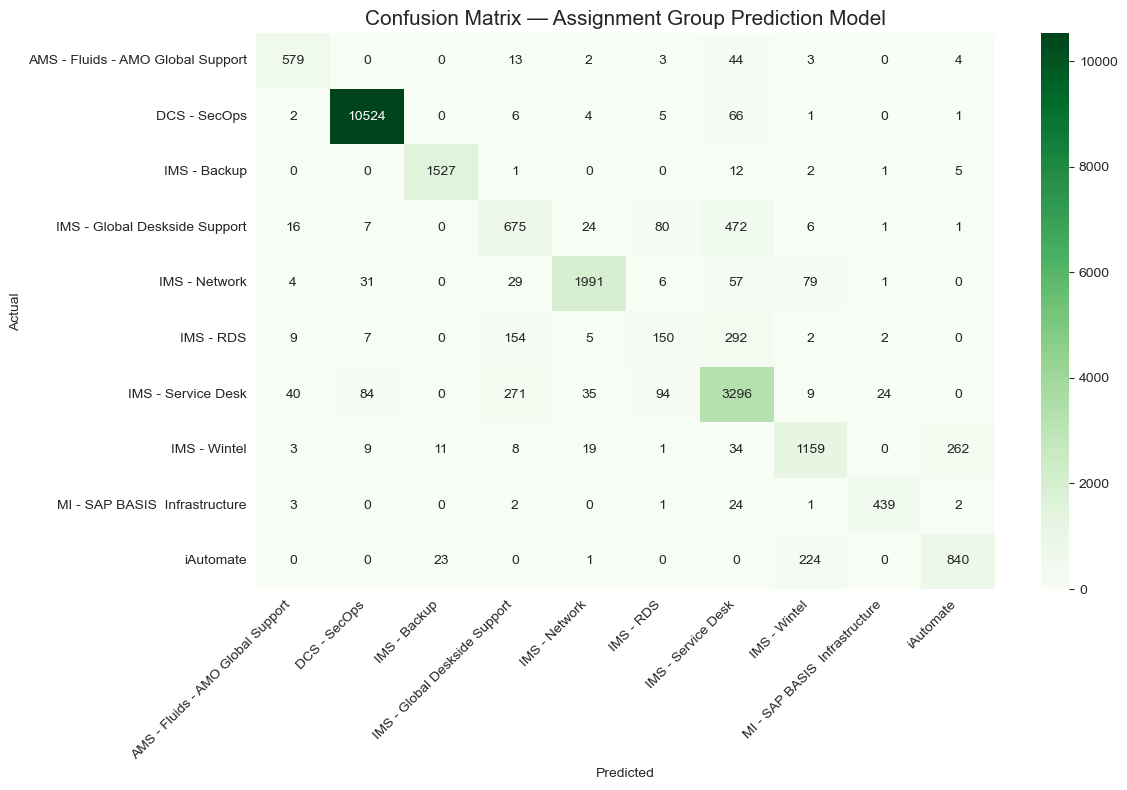

Confusion Matrix 2 done! ✅


In [16]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix - Category Model
plt.figure(figsize=(12, 8))
cm1 = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_model.classes_,
            yticklabels=category_model.classes_)
plt.title('Confusion Matrix — Category Prediction Model', fontsize=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart7_confusion_category.png')
plt.show()
print("Confusion Matrix 1 done! ✅")

# Confusion Matrix - Assignment Group Model
plt.figure(figsize=(12, 8))
cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=assignment_model.classes_,
            yticklabels=assignment_model.classes_)
plt.title('Confusion Matrix — Assignment Group Prediction Model', fontsize=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart8_confusion_assignment.png')
plt.show()
print("Confusion Matrix 2 done! ✅")

In [17]:
# Function to predict both category and assignment group
def predict_ticket(description):
    description = str(description)
    category = category_model.predict([description])[0]
    assign_input = description + " " + str(category)
    assignment = assignment_model.predict([assign_input])[0]
    return category, assignment

# Test with sample tickets
test_tickets = [
    "Unable to login to SAP system, getting authentication error",
    "Laptop screen is blank and not turning on after restart",
    "Network drive is not accessible from office location",
    "New employee needs access to email and office applications",
    "Security alert triggered on workstation needs investigation"
]

print("🤖 Live Ticket Auto-Classification Demo")
print("=" * 65)
for ticket in test_tickets:
    cat, assign = predict_ticket(ticket)
    print(f"📝 Description  : {ticket}")
    print(f"📂 Category     : {cat}")
    print(f"👥 Assign To    : {assign}")
    print("-" * 65)

🤖 Live Ticket Auto-Classification Demo
📝 Description  : Unable to login to SAP system, getting authentication error
📂 Category     : Business System
👥 Assign To    : MI - SAP BASIS  Infrastructure
-----------------------------------------------------------------
📝 Description  : Laptop screen is blank and not turning on after restart
📂 Category     : Desktop/Laptop Hardware
👥 Assign To    : IMS - Global Deskside Support
-----------------------------------------------------------------
📝 Description  : Network drive is not accessible from office location
📂 Category     : Business System
👥 Assign To    : IMS - Network
-----------------------------------------------------------------
📝 Description  : New employee needs access to email and office applications
📂 Category     : Desktop/Laptop Software
👥 Assign To    : IMS - Service Desk
-----------------------------------------------------------------
📝 Description  : Security alert triggered on workstation needs investigation
📂 Category    

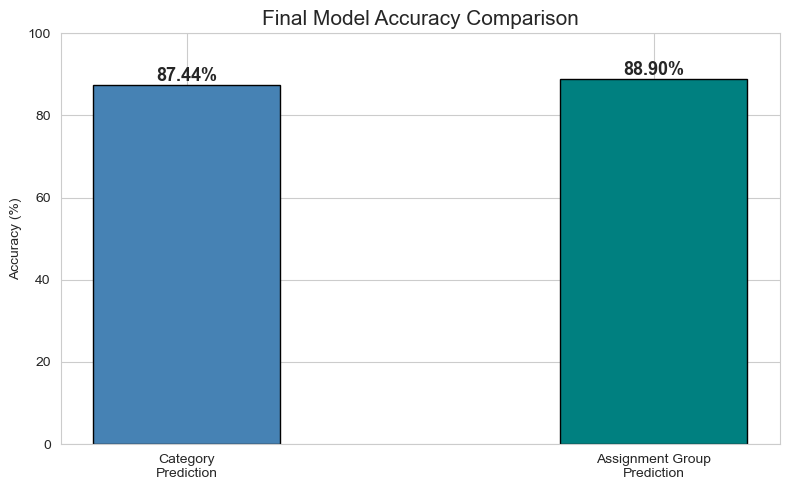

   FINAL PROJECT SUMMARY
📊 Total Tickets Analyzed   : 156,005
📋 Total Features           : 9

📂 Top 5 Categories:
   Security: 59,712
   Business System: 26,643
   Enterprise Hardware: 23,976
   Desktop/Laptop Software: 19,577
   Enterprise Software: 13,623

🚨 Priority Breakdown:
   4 - Low: 101,186
   3 - Moderate: 49,559
   2 - High: 4,049
   1 - Critical: 1,211

🤖 ML Model Results:
   Category Prediction Accuracy    : 87.44%
   Assignment Group Accuracy       : 88.90%
✅ Analysis Complete!


In [18]:
# Final accuracy bar chart
plt.figure(figsize=(8, 5))
models_list = ['Category\nPrediction', 'Assignment Group\nPrediction']
accuracies = [cat_accuracy*100, assign_accuracy*100]
colors = ['steelblue', 'teal']
bars = plt.bar(models_list, accuracies, color=colors,
               edgecolor='black', width=0.4)
plt.title('Final Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             acc + 1, f'{acc:.2f}%',
             ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_final_accuracy.png')
plt.show()

# Print summary
print("=" * 60)
print("   FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"📊 Total Tickets Analyzed   : {len(df):,}")
print(f"📋 Total Features           : {len(df.columns)}")
print(f"\n📂 Top 5 Categories:")
for k, v in df['Category'].value_counts().head(5).items():
    print(f"   {k}: {v:,}")
print(f"\n🚨 Priority Breakdown:")
for k, v in df['Priority'].value_counts().items():
    print(f"   {k}: {v:,}")
print(f"\n🤖 ML Model Results:")
print(f"   Category Prediction Accuracy    : {cat_accuracy*100:.2f}%")
print(f"   Assignment Group Accuracy       : {assign_accuracy*100:.2f}%")
print("=" * 60)
print("✅ Analysis Complete!")